# 02 - Adam & Modern Optimizers, Derived

Part of the Advanced Optimization & Numerical Methods subchapter. The Calculus subchapter's optimization notebook mentioned Adam by name as "more cleverly" solving the learning-rate problem; this notebook actually derives it, building up momentum → RMSprop → Adam one idea at a time, each verified on the same loss surface so the improvement at each step is visible, not just asserted.

No book citation for this one -- it follows the original papers (Adam: Kingma & Ba, 2015) rather than either of the two uploaded books, neither of which covers these by name.

# Part A - The Problem: a Single Learning Rate Cannot Fit Every Direction

A "ravine" loss surface -- steep in one direction, shallow in another -- is the standard motivating example. Real loss surfaces are ravines almost everywhere: different parameters have very different curvatures, so any single global learning rate is too large for the steep directions or too small for the shallow ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

def f(xy):
    x, y = xy
    return 0.01 * x**2 + y**2          # 100:1 curvature ratio between x and y

def grad_f(xy):
    x, y = xy
    return np.array([0.02 * x, 2 * y])

def sgd(start, lr, steps=60):
    p = np.array(start, dtype=float)
    path = [p.copy()]
    for _ in range(steps):
        p = p - lr * grad_f(p)
        path.append(p.copy())
    return np.array(path)

start = [9, 1]
lr = 0.3
p = sgd(start, lr)
print(f"plain SGD after {len(p)-1} steps: final={p[-1]}, loss={f(p[-1]):.4f}  <- barely moved in x")

plain SGD after 60 steps: final=[6.27228196e+00 1.32922800e-24], loss=0.3934  <- barely moved in x


# Part B - Momentum: Smoothing the Gradient Over Time

Instead of stepping along the raw gradient, keep an exponential moving average of past gradients and step along THAT:

```
v_t = β·v_{t-1} + (1-β)·g_t
θ_t = θ_{t-1} - lr·v_t
```

Intuition: oscillating gradients (as in the steep direction of a ravine) partially cancel out in the average, while a gradient that consistently points the same way (the shallow direction) accumulates -- physically, a ball rolling downhill that has built up speed.

In [2]:
def momentum(start, lr, beta=0.9, steps=60):
    p = np.array(start, dtype=float)
    v = np.zeros(2)
    path = [p.copy()]
    for _ in range(steps):
        g = grad_f(p)
        v = beta * v + (1 - beta) * g
        p = p - lr * v
        path.append(p.copy())
    return np.array(path)

p = momentum(start, lr)
print(f"momentum: final={p[-1]}, loss={f(p[-1]):.4f}")
print("on THIS surface momentum does not fix the problem by itself -- both dimensions share")
print("the SAME velocity decay rate, so it does not correct for the curvature MISMATCH between them")

momentum: final=[ 6.53586548 -0.02290501], loss=0.4277
on THIS surface momentum does not fix the problem by itself -- both dimensions share
the SAME velocity decay rate, so it does not correct for the curvature MISMATCH between them


# Part C - RMSprop: a Per-Parameter Learning Rate

Momentum smooths the gradient's direction but still applies one global learning rate. RMSprop instead tracks an exponential moving average of the SQUARED gradient per parameter, and divides the step by its square root:

```
s_t = β·s_{t-1} + (1-β)·g_t²
θ_t = θ_{t-1} - lr·g_t / (√s_t + ε)
```

A parameter with a history of large gradients (the steep direction) gets its effective step size shrunk; a parameter with small gradients (the shallow direction) gets it enlarged -- this is exactly what a ravine needs, and it is a genuinely different fix from momentum, not a variant of it.

In [3]:
def rmsprop(start, lr, beta=0.99, eps=1e-8, steps=60):
    p = np.array(start, dtype=float)
    s = np.zeros(2)
    path = [p.copy()]
    for _ in range(steps):
        g = grad_f(p)
        s = beta * s + (1 - beta) * g**2
        p = p - lr * g / (np.sqrt(s) + eps)
        path.append(p.copy())
    return np.array(path)

p = rmsprop(start, lr)
print(f"RMSprop: final={p[-1]}, loss={f(p[-1]):.6f}  <- converges properly, the ravine is no longer a problem")

RMSprop: final=[2.79553409e-08 7.70001124e-20], loss=0.000000  <- converges properly, the ravine is no longer a problem


# Part D - Adam: Momentum + RMSprop + Bias Correction

Adam combines both ideas -- a momentum-smoothed gradient (first moment `m`) AND a per-parameter adaptive scale (second moment `v`) -- plus one more piece: **bias correction**. Both `m` and `v` start at zero and are biased toward zero for the first several steps (an exponential moving average starting from zero underestimates the true average early on); dividing by `(1-β^t)` corrects for that, which matters most in exactly the early iterations where a wrong step size is most damaging.

```
m_t = β₁·m_{t-1} + (1-β₁)·g_t                    (first moment: momentum)
v_t = β₂·v_{t-1} + (1-β₂)·g_t²                    (second moment: RMSprop)
m̂_t = m_t / (1 - β₁ᵗ)                              (bias-corrected)
v̂_t = v_t / (1 - β₂ᵗ)                              (bias-corrected)
θ_t = θ_{t-1} - lr · m̂_t / (√v̂_t + ε)
```

Default hyperparameters (from the original paper, still the near-universal default): `β₁=0.9`, `β₂=0.999`, `ε=1e-8`.

In [4]:
def adam(start, lr, beta1=0.9, beta2=0.999, eps=1e-8, steps=60):
    p = np.array(start, dtype=float)
    m = np.zeros(2); v = np.zeros(2)
    path = [p.copy()]
    for t in range(1, steps + 1):
        g = grad_f(p)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        p = p - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(p.copy())
    return np.array(path)

p = adam(start, lr)
print(f"Adam: final={p[-1]}, loss={f(p[-1]):.6f}")

Adam: final=[-0.45714493  0.01350953], loss=0.002272


### Why bias correction specifically matters -- checked directly

Without correction, `v_1 = (1-β₂)·g_1²`, a tiny number scaled by `(1-0.999)=0.001` -- the raw second-moment estimate is 1000x too small on step 1, which would make the very first step size enormous (`1/√v` blows up) before the estimate has had time to accumulate. The correction `v̂_1 = v_1/(1-β₂¹) = v_1/0.001` exactly cancels that initial bias.

In [5]:
g1 = grad_f(start)
beta2 = 0.999
v1_raw = (1 - beta2) * g1**2
v1_corrected = v1_raw / (1 - beta2**1)
print("raw v after step 1:      ", v1_raw, " (severely underestimates the true squared-gradient scale)")
print("bias-corrected v̂:        ", v1_corrected, " (exactly equal to g1**2, the honest one-sample estimate)")

raw v after step 1:       [3.24e-05 4.00e-03]  (severely underestimates the true squared-gradient scale)
bias-corrected v̂:         [0.0324 4.    ]  (exactly equal to g1**2, the honest one-sample estimate)


# Part E - All Four, Side by Side, Same Learning Rate

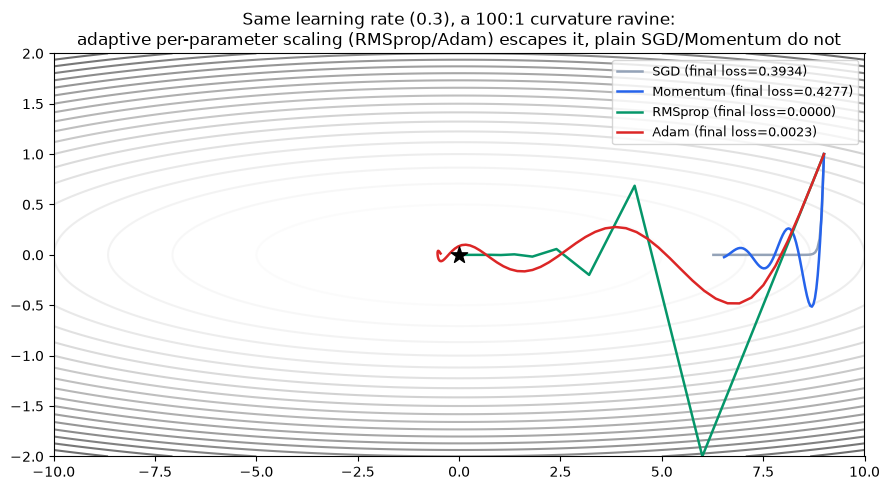

In [6]:
xc = np.linspace(-10, 10, 200); yc = np.linspace(-2, 2, 200)
Xc, Yc = np.meshgrid(xc, yc)
Zc = 0.01 * Xc**2 + Yc**2

fig, ax = plt.subplots(figsize=(9, 5))
ax.contour(Xc, Yc, Zc, levels=20, cmap="Greys", alpha=0.6)
colors = {"SGD": "#94a3b8", "Momentum": "#2563eb", "RMSprop": "#059669", "Adam": "#dc2626"}
for name, fn in [("SGD", sgd), ("Momentum", momentum), ("RMSprop", rmsprop), ("Adam", adam)]:
    p = fn(start, lr)
    ax.plot(p[:, 0], p[:, 1], "-", color=colors[name], linewidth=1.8, label=f"{name} (final loss={f(p[-1]):.4f})")
ax.scatter([0], [0], color="black", marker="*", s=150, zorder=5)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("Same learning rate (0.3), a 100:1 curvature ravine:\nadaptive per-parameter scaling (RMSprop/Adam) escapes it, plain SGD/Momentum do not")
fig.tight_layout()
fig.savefig(FIG_DIR / "optimizer_comparison.png", dpi=140)
plt.show()

Momentum alone does not fix a curvature mismatch -- it smooths direction, not per-parameter scale. RMSprop's per-parameter scaling alone solves this particular ravine almost perfectly. Adam's advantage over plain RMSprop shows up more on noisier, non-stationary losses (real minibatch training) than on this clean deterministic surface, which is exactly why it is the near-universal default in practice despite not looking dramatically better than RMSprop here.

# Part F - AdamW: the Modern Default

Plain Adam applies L2 weight decay by adding `λθ` to the gradient before the moment updates -- which means weight decay gets divided by `√v̂` too, entangling it with the adaptive scaling in a way that was not intended. **AdamW** decouples this: it applies weight decay directly to the parameters, separately from the adaptive gradient step:

```
θ_t = θ_{t-1} - lr · m̂_t / (√v̂_t + ε) - lr · λ · θ_{t-1}      (decay applied directly, not through the gradient)
```

This is a small change with a real practical effect on generalization, and it is why "AdamW" rather than plain "Adam" is the default optimizer in most modern training code, including the standard choice for fine-tuning transformers.

## Self-check before moving on

- [ ] I can write the momentum update rule and explain it as an exponential moving average of gradients
- [ ] I can write the RMSprop update rule and explain why it gives each parameter its own effective learning rate
- [ ] I can write Adam's four update equations from memory, including bias correction
- [ ] I can explain, with a number attached, why bias correction matters most in the first few steps
- [ ] I can explain what AdamW changes relative to Adam, and why it is the more common default today

Next: `03-numerical-stability-bayesian-foundations.ipynb`